|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Running models on a GPU<h1>|
|<h2>Lecture:</h2>|<h1><b>Implementation<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [12]:
# import libraries
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time

# Select the processor device

In [13]:
## Note: To run models on a GPU you must select from the menu:
#   -> Runtime
#     -> Change runtime type
#       -> Hardware accelerator
#         -> GPU

In [14]:
# use GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


# Build a simple model

In [15]:
net = nn.Sequential(
    nn.Linear(20,100),
    nn.ReLU(),
    nn.Linear(100,500),
    nn.ReLU(),
    nn.Linear(500,30),
    nn.ReLU(),
    nn.Linear(30,2)
      )

# Make some data

In [16]:
# just some random fluff
data   = torch.randn((1000,20)) # samples X features
labels = torch.randint(low=0,high=2,size=(1,1000))

# Send the model and the data to the GPU

In [17]:
# model
net.to(device)

# data
data   = data.to(device)
labels = labels.to(device)

In [18]:
data

tensor([[-2.2697,  1.4705, -1.5052,  ..., -0.4051, -0.9538,  0.6205],
        [ 0.2225,  0.5033, -0.7189,  ...,  0.6888,  0.9751,  0.3897],
        [-1.3119, -0.3146, -0.1435,  ..., -0.0039,  2.1058,  0.0269],
        ...,
        [ 2.1284,  0.5194, -1.5427,  ..., -0.7332,  0.3339, -1.2769],
        [-1.1966, -0.0903, -1.5414,  ..., -0.2415, -0.3324, -0.8649],
        [-0.0940, -0.7409,  0.3001,  ...,  0.9139, -1.6765, -0.6592]],
       device='cuda:0')

In [19]:
# you can also create data directly on the GPU
dataG = torch.randn((1000,20),device=device)
dataC = torch.randn((1000,20),device='cpu')

print(data.device)
print(dataG.device)
print(dataC.device)

cuda:0
cuda:0
cpu


# Getting results from the model

In [20]:
output = net(data)

In [21]:
output.device

device(type='cuda', index=0)

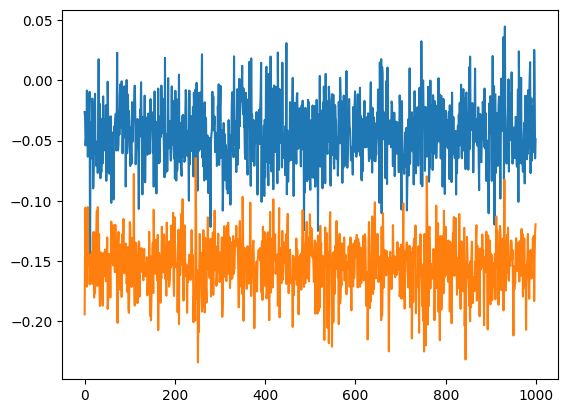

In [23]:
# try to plot the data
# plt.plot(output.detach());

plt.plot(output.detach().cpu());

# Experiment: Computation time

In [24]:
# start the clock
starttime = time.process_time()

# move, run, retrieve
device = 'cuda:0'
net.to(device)
data   = data.to(device)
labels = labels.to(device)
output = net(data).detach().cpu()

# stop the clock
GPUtime = 1000*(time.process_time() - starttime)

In [25]:
# start the clock
starttime = time.process_time()

# move, run, retrieve
device = 'cpu'
net.to(device)
data   = data.to(device)
labels = labels.to(device)
output = net(data).detach().cpu()

# stop the clock
CPUtime = 1000*(time.process_time() - starttime)

In [26]:
# time in ms
[CPUtime,GPUtime]

[14.486286000000348, 2.8974729999999838]

In [27]:
# but maybe "sending" it to the CPU takes too much overhead?

In [28]:
# recreate network and data
net  = nn.Sequential(nn.Linear(20,100),nn.ReLU(),nn.Linear(100,500),nn.ReLU(),nn.Linear(500,30),nn.ReLU(),nn.Linear(30,2))
data = torch.randn((1000,20))

# rerun the experiment
starttime = time.process_time()
output    = net(data).detach()
CPUtime2  = 1000*(time.process_time() - starttime)

# report the results
[CPUtime2,CPUtime,GPUtime]

[1.4266190000000734, 14.486286000000348, 2.8974729999999838]